# AI-Driven Phishing Email Detection Using Natural Language Processing

### Machine Learning Project

**Dataset:** Phishing Email Dataset

**Objective:**

Build a machine learning model that can classify an email as **Phishing** or **Legitimate** using Natural Language Processing (NLP) and different machine learning algorithms. The project includes data preprocessing, feature extraction, model training, evaluation, and comparison of multiple classifiers.

## Step 1 : Import Required Libraries

In [113]:
!pip install wordcloud

In [114]:
# Libraries for data manipulation
import pandas as pd
import numpy as np

# Libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Libraries for text processing
import re
import string
import nltk
import warnings

# NLTK tools
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Library for displaying important words
from wordcloud import WordCloud

# Machine learning utility
from sklearn.model_selection import train_test_split

# Ignore warning messages
warnings.filterwarnings("ignore")

## Step 2 : Download Required NLTK Resources

In [115]:
# Download the required NLTK resources

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## Step 3 : Load the Dataset

In this step, we load the phishing email dataset into a Pandas DataFrame. 
Loading the dataset is the first step before performing data analysis and preprocessing.

In [116]:
# Load the phishing email dataset

df = pd.read_csv("phishing-email.csv")

# Display the first five rows
df.head()


,text,label
0,Subject: Office maintenance\n\nThanks for your...,0
1,"Hello, your profile has been locked. Use the s...",1
2,"Hi there, congratulations! You are the winner ...",1
3,"Attention, this is the fraud prevention accoun...",1
4,"Notice, your profile has been restricted. Use ...",1


In [117]:
import os

print(os.getcwd())

c:\Users\HP\Pictures\RAKESH\Python\AI-Driven-Phishing-Email-Detection-main\notebook


## Step 4 : Understanding the Dataset

Before preprocessing the data, it is important to understand its structure. In this step, we examine the size of the dataset, column names, data types, and sample records.

In [118]:
# Display the number of rows and columns

print("Dataset Shape:", df.shape)

Dataset Shape: (10000, 2)


In [119]:
# Display the column names

df.columns

Index(['text', 'label'], dtype='str')

In [120]:
# Display information about the dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    10000 non-null  str  
 1   label   10000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 2.5 MB


In [121]:
# Display the first five records

df.head()

,text,label
0,Subject: Office maintenance\n\nThanks for your...,0
1,"Hello, your profile has been locked. Use the s...",1
2,"Hi there, congratulations! You are the winner ...",1
3,"Attention, this is the fraud prevention accoun...",1
4,"Notice, your profile has been restricted. Use ...",1


In [122]:
# Display five random records

df.sample(5)

,text,label
6121,Subject: Conference registration\n\nThanks for...,0
8943,Subject: Networking event details\n\nAttaching...,0
3140,"Attention, the IT department detected a malwar...",1
8798,Subject: Office maintenance\n\nQuick reminder ...,0
2186,"Hi there, we talked about meeting again after ...",1


## Step 5 : Check Missing Values

Missing values can affect the performance of machine learning models. In this step, we check whether the dataset contains any missing values.

In [123]:
# Check missing values in each column

missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
text     0
label    0
dtype: int64


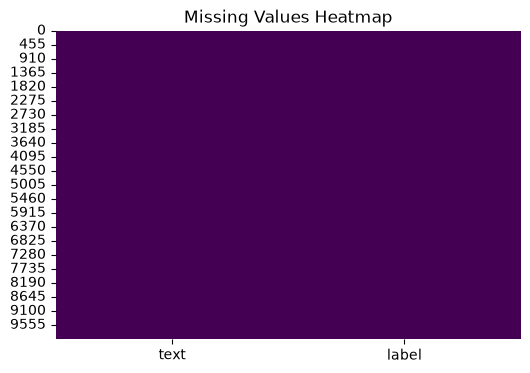

In [124]:
# Visualize missing values

plt.figure(figsize=(6,4))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")

plt.title("Missing Values Heatmap")
plt.show()

## Step 6 : Check Duplicate Records

Duplicate records may reduce the quality of the dataset and affect model performance. Therefore, we check whether duplicate emails are present.

In [125]:
# Count duplicate records

duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 44


In [126]:
# Remove duplicate records if present

df.drop_duplicates(inplace=True)

print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape After Removing Duplicates: (9956, 2)


## Step 7 : Basic Statistics

In this step, we display basic statistical information about the dataset to better understand its structure.

In [127]:
# Display statistical summary

df.describe(include="all")

,text,label
count,9956,9956.000000
unique,9956,NaN
top,Subject: Office maintenance\n\nThanks for your...,NaN
freq,1,NaN
mean,NaN,0.602652
std,NaN,0.489374
min,NaN,0.000000
25%,NaN,0.000000
50%,NaN,1.000000
75%,NaN,1.000000


## Step 8 : Distribution of Email Classes

The target variable contains two classes:

- 0 → Legitimate Email
- 1 → Phishing Email

In this step, we examine the class distribution.

In [128]:
# Count the number of emails in each class

df["label"].value_counts()

label
1    6000
0    3956
Name: count, dtype: int64

In [129]:
# Display class distribution using percentage

df["label"].value_counts(normalize=True) * 100

label
1    60.265167
0    39.734833
Name: proportion, dtype: float64

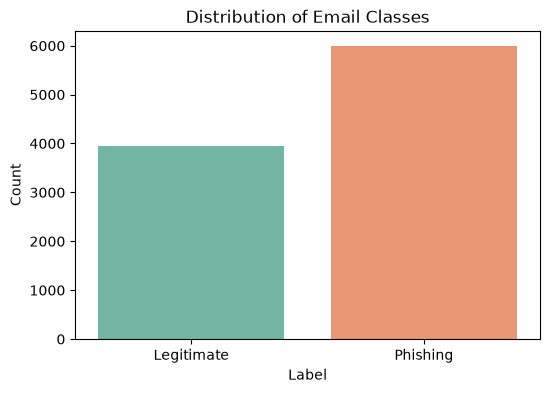

In [130]:
# Visualize class distribution

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="label", palette="Set2")

plt.title("Distribution of Email Classes")
plt.xlabel("Label")
plt.ylabel("Count")

plt.xticks([0,1],["Legitimate","Phishing"])

plt.show()

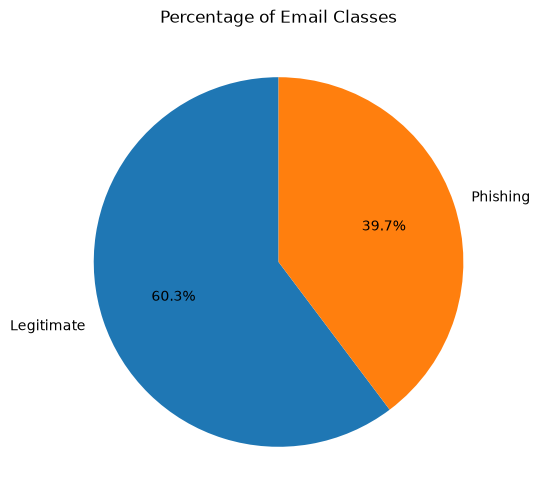

In [131]:
# Plot class distribution using pie chart

class_counts = df["label"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(class_counts,
        labels=["Legitimate","Phishing"],
        autopct="%1.1f%%",
        startangle=90)

plt.title("Percentage of Email Classes")

plt.show()

## Step 9 : Exploratory Data Analysis

In this section, we perform exploratory data analysis (EDA) to better understand the characteristics of the email dataset. We analyze different properties of the email text such as the number of characters, words, and sentences. These analyses help us understand the dataset before applying text preprocessing and machine learning techniques.

In [132]:
# Calculate the number of characters in each email

df["email_length"] = df["text"].apply(len)

# Display first five records

df[["text", "email_length"]].head()

,text,email_length
0,Subject: Office maintenance\n\nThanks for your...,190
1,"Hello, your profile has been locked. Use the s...",222
2,"Hi there, congratulations! You are the winner ...",236
3,"Attention, this is the fraud prevention accoun...",321
4,"Notice, your profile has been restricted. Use ...",200


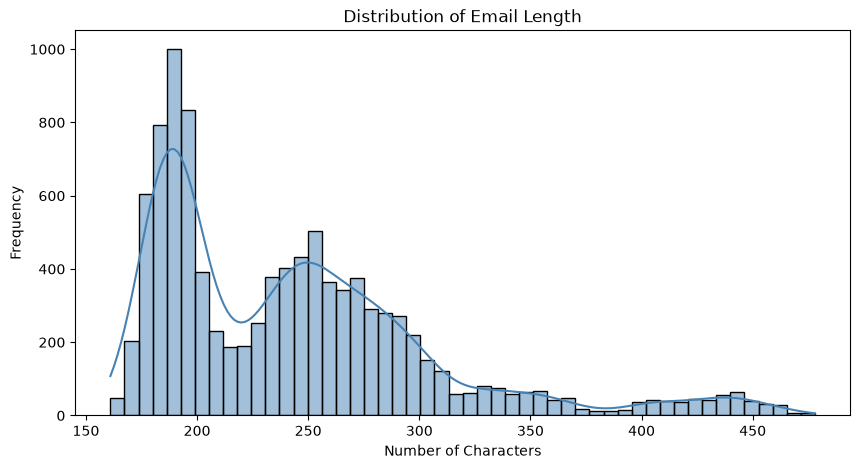

In [133]:
# Plot distribution of email length

plt.figure(figsize=(10,5))

sns.histplot(df["email_length"],
             bins=50,
             kde=True,
             color="steelblue")

plt.title("Distribution of Email Length")

plt.xlabel("Number of Characters")

plt.ylabel("Frequency")

plt.show()

### Word Count Analysis

The number of words in an email can provide useful information. Phishing emails often contain different writing styles and lengths compared to legitimate emails.

In [134]:
# Calculate number of words

df["word_count"] = df["text"].apply(lambda x: len(str(x).split()))

df[["word_count"]].head()

,word_count
0,34
1,34
2,39
3,47
4,31


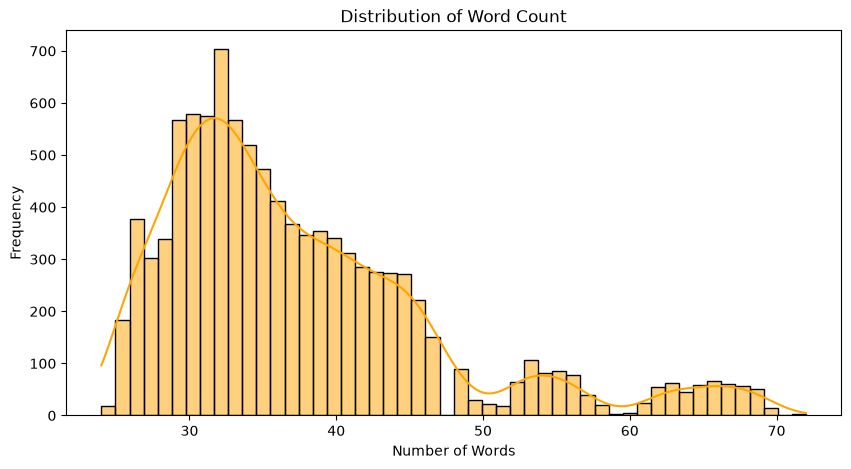

In [135]:
# Plot word count distribution

plt.figure(figsize=(10,5))

sns.histplot(df["word_count"],
             bins=50,
             kde=True,
             color="orange")

plt.title("Distribution of Word Count")

plt.xlabel("Number of Words")

plt.ylabel("Frequency")

plt.show()

In [136]:
# Count number of sentences

df["sentence_count"] = df["text"].apply(
    lambda x: len(str(x).split("."))
)

df[["sentence_count"]].head()

,sentence_count
0,4
1,4
2,4
3,5
4,4


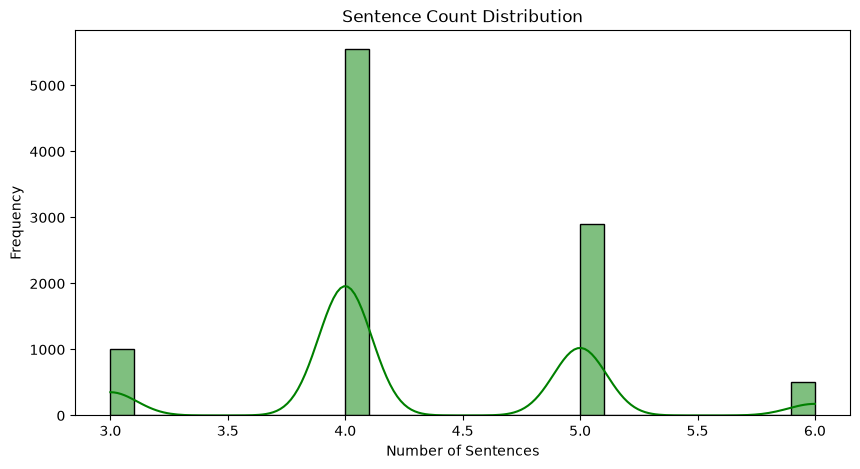

In [137]:
# Plot sentence count

plt.figure(figsize=(10,5))

sns.histplot(df["sentence_count"],
             bins=30,
             color="green",
             kde=True)

plt.title("Sentence Count Distribution")

plt.xlabel("Number of Sentences")

plt.ylabel("Frequency")

plt.show()

### Comparison of Email Length

Here we compare the average email length between legitimate and phishing emails.

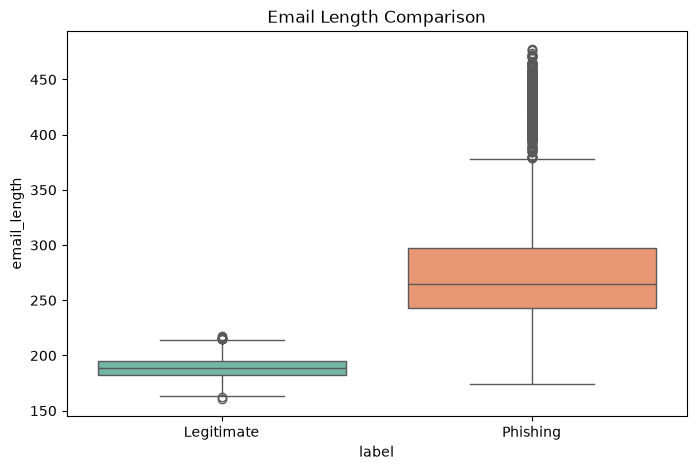

In [138]:
# Compare email length using box plot

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="label",
    y="email_length",
    palette="Set2"
)

plt.xticks([0,1],["Legitimate","Phishing"])

plt.title("Email Length Comparison")

plt.show()

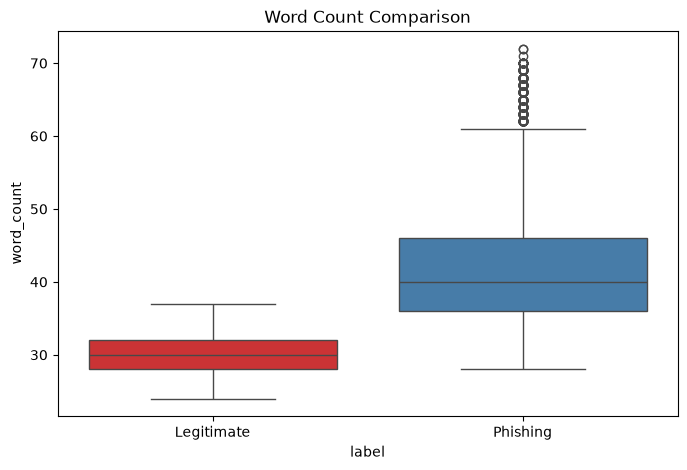

In [139]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="label",
    y="word_count",
    palette="Set1"
)

plt.xticks([0,1],["Legitimate","Phishing"])

plt.title("Word Count Comparison")

plt.show()

In [140]:
df[["email_length",
    "word_count",
    "sentence_count"]].describe()

,email_length,word_count,sentence_count
count,9956.000000,9956.000000,9956.000000
mean,243.653074,37.509341,4.291382
std,63.471214,9.602309,0.712640
min,161.000000,24.000000,3.000000
25%,192.000000,31.000000,4.000000
50%,235.000000,35.000000,4.000000
75%,274.000000,42.000000,5.000000
max,478.000000,72.000000,6.000000


## Step 10 : Text Preprocessing

Text preprocessing is an important step in Natural Language Processing (NLP). Email text often contains HTML tags, URLs, numbers, punctuation, and common words that do not contribute much to the prediction process. In this step, we clean the email text and prepare it for feature extraction and machine learning.

In [141]:
# Initialize stop words and lemmatizer

stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

print("Stopwords loaded successfully.")

Stopwords loaded successfully.


### Text Cleaning Function

The following function performs basic preprocessing operations on the email text.

In [142]:
def clean_text(text):
    """
    This function performs basic text preprocessing.

    Steps:
    1. Convert text to lowercase
    2. Remove URLs
    3. Remove email addresses
    4. Remove HTML tags
    5. Remove numbers
    6. Remove punctuation
    7. Remove extra spaces
    """

    # Convert text to string
    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

### Apply Text Cleaning

Now we apply the cleaning function to every email in the dataset.

In [143]:
# Create a new column containing cleaned text

df["clean_text"] = df["text"].apply(clean_text)

# Display sample records

df[["text", "clean_text"]].head()

,text,clean_text
0,Subject: Office maintenance\n\nThanks for your...,subject office maintenance thanks for your hel...
1,"Hello, your profile has been locked. Use the s...",hello your profile has been locked use the sec...
2,"Hi there, congratulations! You are the winner ...",hi there congratulations you are the winner of...
3,"Attention, this is the fraud prevention accoun...",attention this is the fraud prevention account...
4,"Notice, your profile has been restricted. Use ...",notice your profile has been restricted use th...


### Tokenization

Tokenization is the process of splitting text into individual words called tokens.

In [144]:
# Function for tokenization

def tokenize_text(text):
    return word_tokenize(text)

In [145]:
# Apply tokenization

nltk.download('punkt_tab')
df["tokens"] = df["clean_text"].apply(tokenize_text)

df[["clean_text", "tokens"]].head()

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...


[nltk_data]   Package punkt_tab is already up-to-date!


,clean_text,tokens
0,subject office maintenance thanks for your hel...,"[subject, office, maintenance, thanks, for, yo..."
1,hello your profile has been locked use the sec...,"[hello, your, profile, has, been, locked, use,..."
2,hi there congratulations you are the winner of...,"[hi, there, congratulations, you, are, the, wi..."
3,attention this is the fraud prevention account...,"[attention, this, is, the, fraud, prevention, ..."
4,notice your profile has been restricted use th...,"[notice, your, profile, has, been, restricted,..."


### Stopword Removal

Stopwords are common words such as "is", "the", and "are" that usually do not provide useful information for text classification.

In [146]:
# Function to remove stopwords

def remove_stopwords(words):

    filtered_words = []

    for word in words:

        if word not in stop_words:

            filtered_words.append(word)

    return filtered_words

In [147]:
# Apply stopword removal

df["tokens"] = df["tokens"].apply(remove_stopwords)

df[["tokens"]].head()

,tokens
0,"[subject, office, maintenance, thanks, help, a..."
1,"[hello, profile, locked, use, secure, link, ve..."
2,"[hi, congratulations, winner, refund, collect,..."
3,"[attention, fraud, prevention, accounts, team,..."
4,"[notice, profile, restricted, use, secure, lin..."


### Lemmatization

Lemmatization converts words to their root form without changing their meaning.

In [148]:
# Function for lemmatization

def lemmatize_words(words):

    return [lemmatizer.lemmatize(word) for word in words]

In [149]:
# Apply lemmatization

df["tokens"] = df["tokens"].apply(lemmatize_words)

df[["tokens"]].head()

,tokens
0,"[subject, office, maintenance, thanks, help, a..."
1,"[hello, profile, locked, use, secure, link, ve..."
2,"[hi, congratulation, winner, refund, collect, ..."
3,"[attention, fraud, prevention, account, team, ..."
4,"[notice, profile, restricted, use, secure, lin..."


### Convert Tokens Back to Text

Machine learning algorithms require text instead of lists. Therefore, we convert the tokens back into complete sentences.

In [150]:
# Join words into a sentence

df["processed_text"] = df["tokens"].apply(lambda words: " ".join(words))

df[["processed_text"]].head()

,processed_text
0,subject office maintenance thanks help analysi...
1,hello profile locked use secure link verify us...
2,hi congratulation winner refund collect gift p...
3,attention fraud prevention account team securi...
4,notice profile restricted use secure link rese...


In [151]:
# Compare original and processed text

df[["text",
    "clean_text",
    "processed_text"]].head(10)

,text,clean_text,processed_text
0,Subject: Office maintenance\n\nThanks for your...,subject office maintenance thanks for your hel...,subject office maintenance thanks help analysi...
1,"Hello, your profile has been locked. Use the s...",hello your profile has been locked use the sec...,hello profile locked use secure link verify us...
2,"Hi there, congratulations! You are the winner ...",hi there congratulations you are the winner of...,hi congratulation winner refund collect gift p...
3,"Attention, this is the fraud prevention accoun...",attention this is the fraud prevention account...,attention fraud prevention account team securi...
4,"Notice, your profile has been restricted. Use ...",notice your profile has been restricted use th...,notice profile restricted use secure link rese...
5,"Attention, this is an urgent notice regarding ...",attention this is an urgent notice regarding y...,attention urgent notice regarding account acce...
6,Subject: Training session notes\n\nI booked th...,subject training session notes i booked the la...,subject training session note booked lab next ...
7,Subject: Meeting follow-up\n\nThanks for atten...,subject meeting followup thanks for attending ...,subject meeting followup thanks attending work...
8,"Subject: Research discussion\n\nGood morning, ...",subject research discussion good morning the u...,subject research discussion good morning updat...
9,"Attention, your account has been restricted. U...",attention your account has been restricted use...,attention account restricted use secure link r...


## Step 11 : Feature Engineering

Feature engineering is the process of extracting useful information from raw email text. These features help machine learning models better understand the characteristics of phishing and legitimate emails.

In this step, we create several handcrafted features from the email text.

### URL Count

Phishing emails often contain malicious links that encourage users to click on them. Therefore, we count the number of URLs present in each email.

In [152]:
# Count the number of URLs in each email

df["url_count"] = df["text"].apply(
    lambda x: len(re.findall(r'http[s]?://\S+|www\.\S+', str(x)))
)

df[["url_count"]].head()

,url_count
0,0
1,0
2,0
3,0
4,0


### Email Address Count

Some phishing emails contain fake sender or contact email addresses. This feature counts the number of email addresses in each email.

In [153]:
# Count email addresses

df["email_count"] = df["text"].apply(
    lambda x: len(re.findall(r'\S+@\S+', str(x)))
)

df[["email_count"]].head()

,email_count
0,0
1,0
2,0
3,0
4,0


### Digit Count

Phishing emails often contain numbers such as OTPs, account numbers, transaction IDs, or reward amounts.

In [154]:
# Count digits

df["digit_count"] = df["text"].apply(
    lambda x: sum(character.isdigit() for character in str(x))
)

df[["digit_count"]].head()

,digit_count
0,0
1,0
2,5
3,0
4,1


### Special Character Count

Special characters are frequently used in phishing emails to attract attention or disguise malicious content.

In [155]:
# Count special characters

df["special_char_count"] = df["text"].apply(
    lambda x: sum(
        not character.isalnum() and not character.isspace()
        for character in str(x)
    )
)

df[["special_char_count"]].head()

,special_char_count
0,6
1,6
2,10
3,8
4,6


### Suspicious Keyword Count

Certain words commonly appear in phishing emails, such as "verify", "password", "urgent", and "click". We count the occurrence of these keywords.

In [156]:
# List of suspicious words

suspicious_words = [
    "verify",
    "bank",
    "password",
    "login",
    "urgent",
    "click",
    "account",
    "security",
    "payment",
    "confirm",
    "limited",
    "offer",
    "free",
    "winner",
    "claim",
    "reward",
    "invoice",
    "update"
]

# Function to count suspicious words

def count_suspicious_words(text):

    text = str(text).lower()

    count = 0

    for word in suspicious_words:

        count += text.count(word)

    return count

# Apply function

df["suspicious_word_count"] = df["text"].apply(count_suspicious_words)

df[["suspicious_word_count"]].head()

,suspicious_word_count
0,0
1,4
2,3
3,4
4,2


In [157]:
# Display newly created features

df[
    [
        "email_length",
        "word_count",
        "sentence_count",
        "url_count",
        "email_count",
        "digit_count",
        "special_char_count",
        "suspicious_word_count"
    ]
].head()

,email_length,word_count,sentence_count,url_count,email_count,digit_count,special_char_count,suspicious_word_count
0,190,34,4,0,0,0,6,0
1,222,34,4,0,0,0,6,4
2,236,39,4,0,0,5,10,3
3,321,47,5,0,0,0,8,4
4,200,31,4,0,0,1,6,2


In [158]:
# Summary of engineered features

df[
    [
        "email_length",
        "word_count",
        "sentence_count",
        "url_count",
        "email_count",
        "digit_count",
        "special_char_count",
        "suspicious_word_count"
    ]
].describe()

,email_length,word_count,sentence_count,url_count,email_count,digit_count,special_char_count,suspicious_word_count
count,9956.000000,9956.000000,9956.000000,9956.0,9956.0,9956.000000,9956.000000,9956.000000
mean,243.653074,37.509341,4.291382,0.0,0.0,0.446665,8.245380,2.011852
std,63.471214,9.602309,0.712640,0.0,0.0,1.193178,2.930392,1.749409
min,161.000000,24.000000,3.000000,0.0,0.0,0.000000,5.000000,0.000000
25%,192.000000,31.000000,4.000000,0.0,0.0,0.000000,6.000000,1.000000
50%,235.000000,35.000000,4.000000,0.0,0.0,0.000000,7.000000,2.000000
75%,274.000000,42.000000,5.000000,0.0,0.0,0.000000,10.000000,3.000000
max,478.000000,72.000000,6.000000,0.0,0.0,15.000000,17.000000,9.000000


## Step 12 : Feature Extraction using TF-IDF

Machine learning algorithms cannot process raw text directly. Therefore, the preprocessed email text must be converted into numerical features.

In this project, we use the Term Frequency–Inverse Document Frequency (TF-IDF) technique. TF-IDF assigns higher importance to words that occur frequently in a particular email but less frequently across the entire dataset. This helps the model identify important words that distinguish phishing emails from legitimate emails.

In [159]:
# Import TF-IDF Vectorizer

from sklearn.feature_extraction.text import TfidfVectorizer

### Create TF-IDF Features

The TF-IDF Vectorizer converts the processed email text into a numerical matrix. We use both unigrams and bigrams so that the model can learn individual words as well as common word pairs.

In [160]:
# Create TF-IDF vectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

In [161]:
# Convert processed text into TF-IDF features

X_text = tfidf.fit_transform(df["processed_text"])

In [162]:
# Target variable

y = df["label"]

In [163]:
print("TF-IDF Matrix Shape :", X_text.shape)

print("Target Shape :", y.shape)

TF-IDF Matrix Shape : (9956, 5000)
Target Shape : (9956,)


In [164]:
print("Vocabulary Size :", len(tfidf.vocabulary_))

Vocabulary Size : 5000


In [165]:
# Display first 30 feature names

feature_names = tfidf.get_feature_names_out()

print(feature_names[:30])

['aboard' 'aboard attaching' 'aboard booked' 'aboard good' 'aboard hello'
 'aboard hi' 'aboard please' 'aboard quick' 'aboard sharing'
 'aboard thanks' 'access' 'access code' 'access denied' 'access enter'
 'access expire' 'access limited' 'access please' 'access reset'
 'accident' 'accident compliance' 'accident sincere' 'accident traveler'
 'accident traveling' 'account' 'account access' 'account account'
 'account activation' 'account administration' 'account authenticate'
 'account authentication']


In [166]:
tfidf_df = pd.DataFrame(
    X_text[:5].toarray(),
    columns=tfidf.get_feature_names_out()
)

tfidf_df.head()

,aboard,aboard attaching,aboard booked,aboard good,aboard hello,aboard hi,aboard please,aboard quick,aboard sharing,aboard thanks,...,would appreciated,zelle,zelle card,zelle compliance,zelle replacement,zelle transfer,zelle traveler,zoom,zoom desk,zoom president
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Step 13 : Split the Dataset

Before training the machine learning models, the dataset is divided into training and testing sets.

- The training set is used to train the model.
- The testing set is used to evaluate the performance of the trained model.

In this project, we use an 80:20 train-test split.

In [167]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [168]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (7964, 5000)
Testing Features  : (1992, 5000)
Training Labels   : (7964,)
Testing Labels    : (1992,)


## Step 14 : Logistic Regression

Logistic Regression is one of the most commonly used machine learning algorithms for binary classification problems. It serves as a strong baseline model for text classification tasks such as phishing email detection.

In [169]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [170]:
# Create the Logistic Regression model

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model

lr_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [171]:
# Predict on the test data

y_pred_lr = lr_model.predict(X_test)

In [172]:
# Calculate evaluation metrics

accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000


In [173]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       792
           1       1.00      1.00      1.00      1200

    accuracy                           1.00      1992
   macro avg       1.00      1.00      1.00      1992
weighted avg       1.00      1.00      1.00      1992



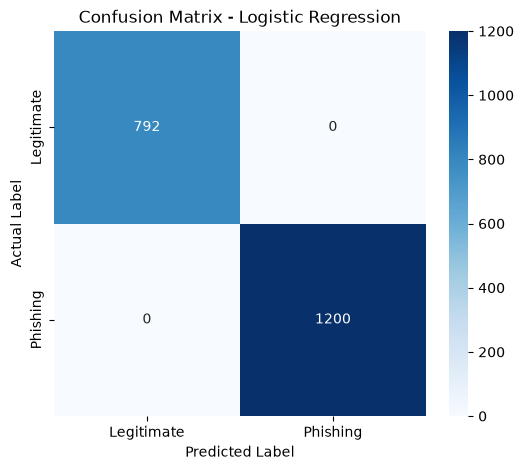

In [174]:
# Plot confusion matrix

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Phishing"],
    yticklabels=["Legitimate", "Phishing"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

## Step 15 : Model Comparison

To identify the best classifier for phishing email detection, multiple machine learning models are trained and evaluated using the same training and testing datasets.

The following models are compared:

- Logistic Regression
- Multinomial Naive Bayes
- Random Forest
- Support Vector Machine
- Multi-Layer Perceptron (MLP)

In [175]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier

In [176]:
# Function to train and evaluate machine learning models

def evaluate_model(model, model_name):

    # Train the model
    model.fit(X_train, y_train)

    # Predict on test data
    predictions = model.predict(X_test)

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_test, predictions))

    return accuracy, precision, recall, f1

In [177]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_results = evaluate_model(
    lr_model,
    "Logistic Regression"
)

Logistic Regression
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       792
           1       1.00      1.00      1.00      1200

    accuracy                           1.00      1992
   macro avg       1.00      1.00      1.00      1992
weighted avg       1.00      1.00      1.00      1992



In [178]:
nb_model = MultinomialNB()

nb_results = evaluate_model(
    nb_model,
    "Multinomial Naive Bayes"
)

Multinomial Naive Bayes
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       792
           1       1.00      1.00      1.00      1200

    accuracy                           1.00      1992
   macro avg       1.00      1.00      1.00      1992
weighted avg       1.00      1.00      1.00      1992



In [179]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_results = evaluate_model(
    rf_model,
    "Random Forest"
)

Random Forest
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       792
           1       1.00      1.00      1.00      1200

    accuracy                           1.00      1992
   macro avg       1.00      1.00      1.00      1992
weighted avg       1.00      1.00      1.00      1992



In [180]:
svm_model = LinearSVC(
    random_state=42
)

svm_results = evaluate_model(
    svm_model,
    "Support Vector Machine"
)

Support Vector Machine
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       792
           1       1.00      1.00      1.00      1200

    accuracy                           1.00      1992
   macro avg       1.00      1.00      1.00      1992
weighted avg       1.00      1.00      1.00      1992



In [181]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=300,
    random_state=42
)

mlp_results = evaluate_model(
    mlp_model,
    "Multi Layer Perceptron"
)

Multi Layer Perceptron
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       792
           1       1.00      1.00      1.00      1200

    accuracy                           1.00      1992
   macro avg       1.00      1.00      1.00      1992
weighted avg       1.00      1.00      1.00      1992



In [182]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Naive Bayes",
        "Random Forest",
        "Support Vector Machine",
        "MLP"
    ],

    "Accuracy":[
        lr_results[0],
        nb_results[0],
        rf_results[0],
        svm_results[0],
        mlp_results[0]
    ],

    "Precision":[
        lr_results[1],
        nb_results[1],
        rf_results[1],
        svm_results[1],
        mlp_results[1]
    ],

    "Recall":[
        lr_results[2],
        nb_results[2],
        rf_results[2],
        svm_results[2],
        mlp_results[2]
    ],

    "F1 Score":[
        lr_results[3],
        nb_results[3],
        rf_results[3],
        svm_results[3],
        mlp_results[3]
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Naive Bayes,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0
3,Support Vector Machine,1.0,1.0,1.0,1.0
4,MLP,1.0,1.0,1.0,1.0


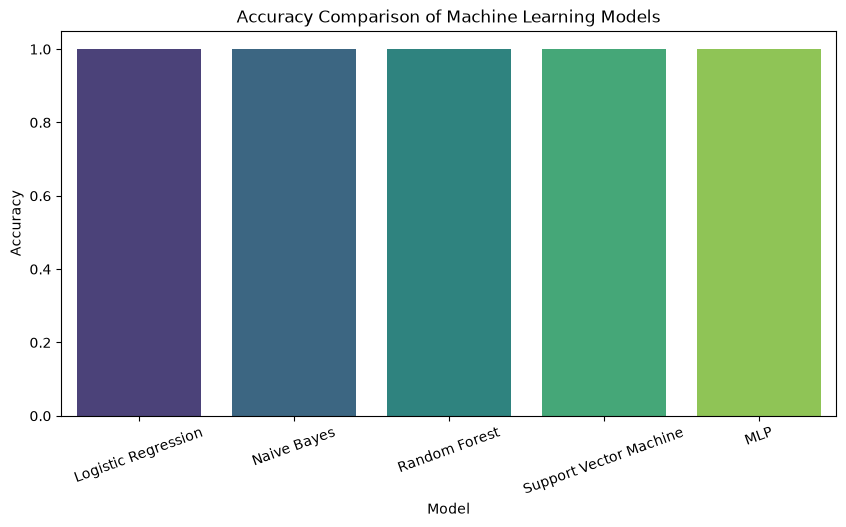

In [183]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy",
    palette="viridis"
)

plt.title("Accuracy Comparison of Machine Learning Models")

plt.xticks(rotation=20)

plt.show()

## Step 16 : Model Evaluation

In this step, we compare the performance of all machine learning models using different evaluation metrics. The best-performing model is selected based on accuracy, precision, recall, and F1-score.

In [184]:
comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Naive Bayes,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0
3,Support Vector Machine,1.0,1.0,1.0,1.0
4,MLP,1.0,1.0,1.0,1.0


In [185]:
# Find the best model

best_model = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

best_model.head(1)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0


In [186]:
print("Best Performing Model")

print(best_model.iloc[0])

Best Performing Model
Model        Logistic Regression
Accuracy                     1.0
Precision                    1.0
Recall                       1.0
F1 Score                     1.0
Name: 0, dtype: object


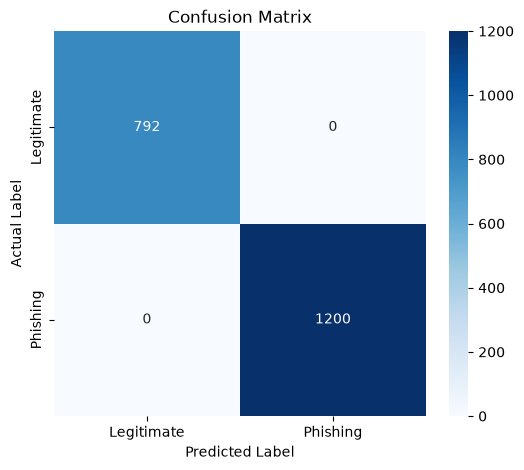

In [187]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Phishing"],
    yticklabels=["Legitimate", "Phishing"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

### Most Important Features

The coefficients learned by Logistic Regression indicate which words contribute the most towards predicting phishing and legitimate emails.

In [188]:
feature_names = tfidf.get_feature_names_out()

coefficients = lr_model.coef_[0]

feature_importance = pd.DataFrame({

    "Feature": feature_names,

    "Coefficient": coefficients

})

feature_importance.head()

,Feature,Coefficient
0,aboard,-0.548323
1,aboard attaching,-0.083295
2,aboard booked,-0.062894
3,aboard good,-0.109334
4,aboard hello,-0.052121


In [189]:
top_phishing = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
).head(20)

top_phishing

,Feature,Coefficient
23,account,3.176659
2182,keywords,2.485047
3805,security,1.700489
10,access,1.612366
4806,verification,1.411803
2947,notice,1.400667
1163,desk,1.286542
3102,password,1.268298
4070,soon,1.260323
1104,dear,1.223132


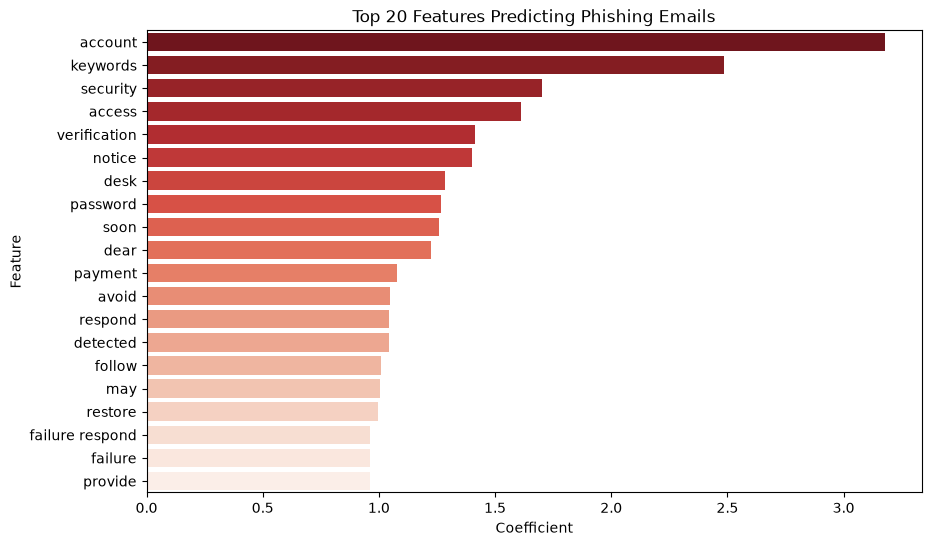

In [190]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_phishing,
    x="Coefficient",
    y="Feature",
    palette="Reds_r"
)

plt.title("Top 20 Features Predicting Phishing Emails")

plt.show()

In [191]:
top_legitimate = feature_importance.sort_values(
    by="Coefficient"
).head(20)

top_legitimatetop_legitimate = feature_importance.sort_values(
    by="Coefficient"
).head(20)

top_legitimate

,Feature,Coefficient
498,best,-4.062652
4219,subject,-4.062652
4422,thanks,-2.693889
1257,draft,-2.551553
4047,slide,-2.404476
1499,feedback,-2.379872
2934,note,-2.176187
1234,document,-1.893877
2571,let know,-1.885332
2570,let,-1.885332


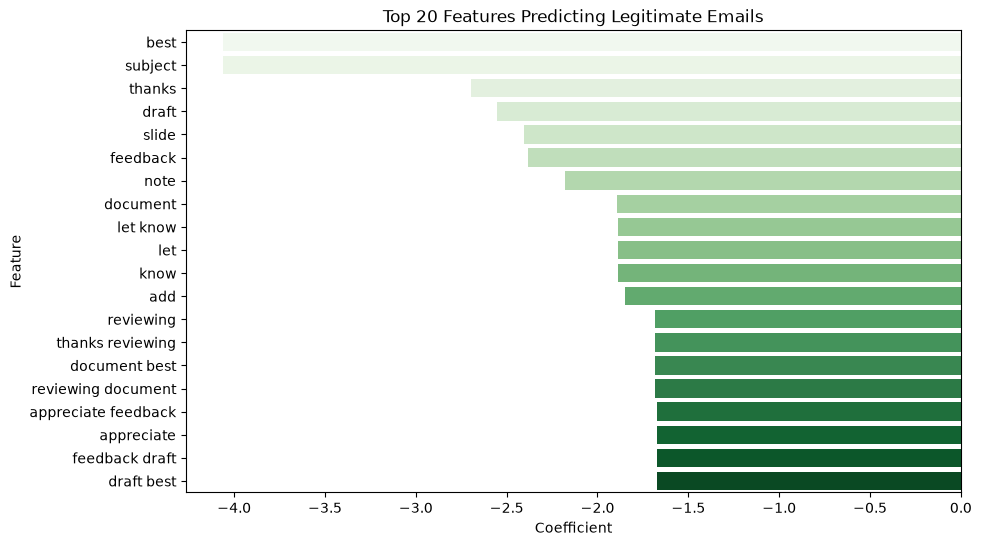

In [192]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_legitimate,
    x="Coefficient",
    y="Feature",
    palette="Greens"
)

plt.title("Top 20 Features Predicting Legitimate Emails")

plt.show()

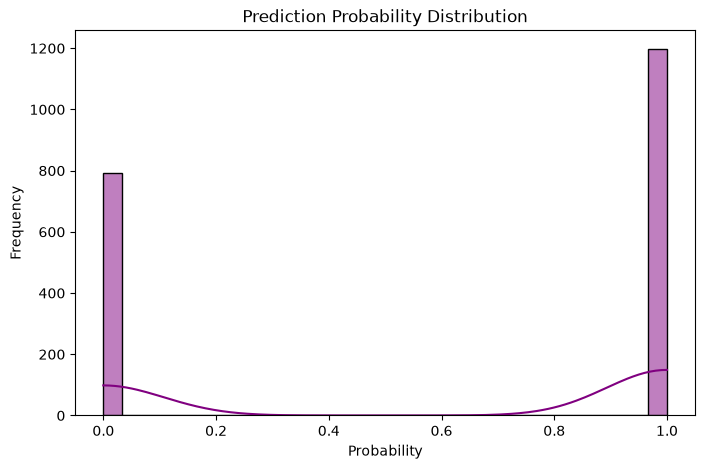

In [193]:
y_prob = rf_model.predict_proba(X_test)[:, 1]

plt.figure(figsize=(8,5))

sns.histplot(
    y_prob,
    bins=30,
    kde=True,
    color="purple"
)

plt.title("Prediction Probability Distribution")

plt.xlabel("Probability")

plt.ylabel("Frequency")

plt.show()

In [194]:
from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(y_test, y_prob)
print(roc_auc)

performance = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Score":[
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]

})

performance

1.0


,Metric,Score
0,Accuracy,1.0
1,Precision,1.0
2,Recall,1.0
3,F1 Score,1.0
4,ROC-AUC,1.0


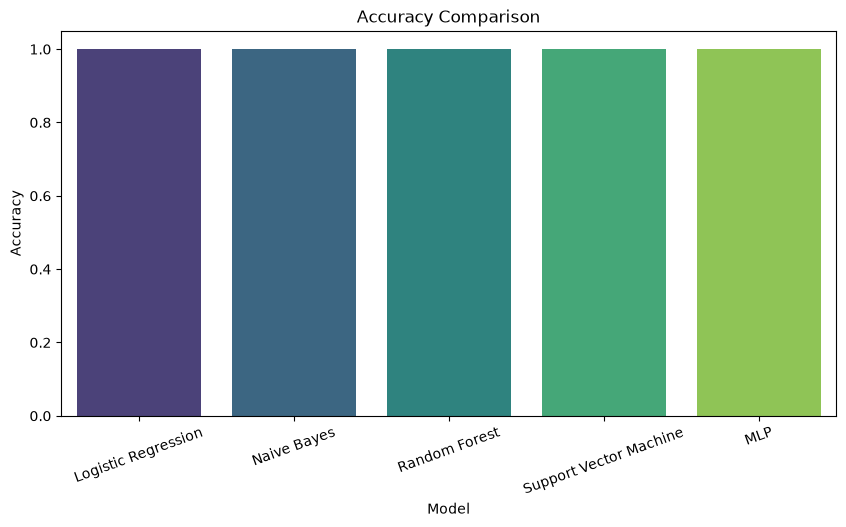

In [195]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy",
    palette="viridis"
)

plt.title("Accuracy Comparison")

plt.xticks(rotation=20)

plt.show()

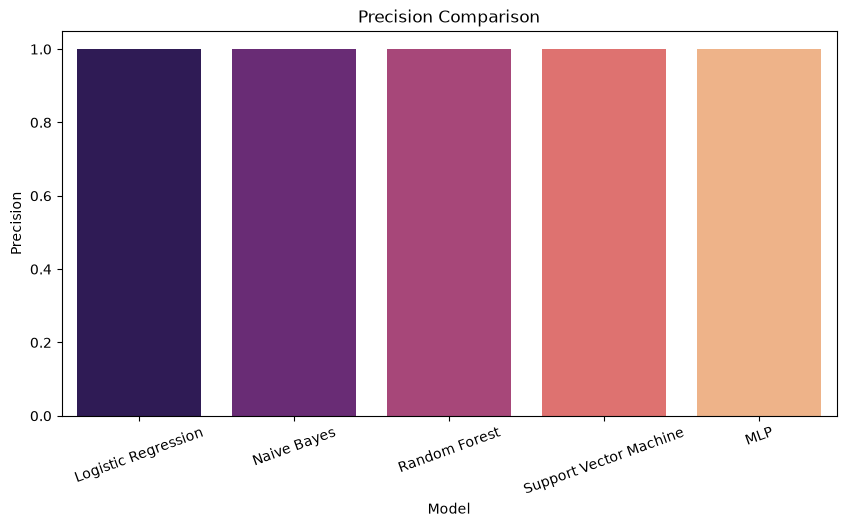

In [196]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Precision",
    palette="magma"
)

plt.title("Precision Comparison")

plt.xticks(rotation=20)

plt.show()

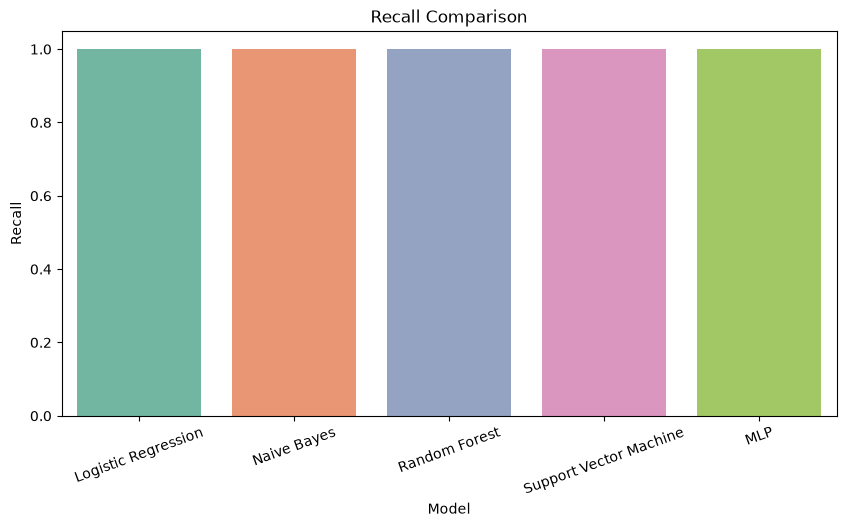

In [197]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Recall",
    palette="Set2"
)

plt.title("Recall Comparison")

plt.xticks(rotation=20)

plt.show()

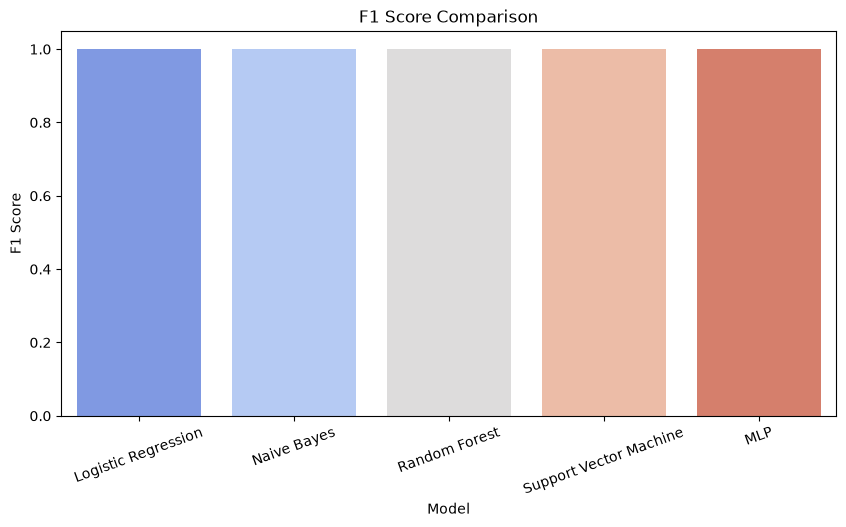

In [198]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="F1 Score",
    palette="coolwarm"
)

plt.title("F1 Score Comparison")

plt.xticks(rotation=20)

plt.show()

## Step 17 : Save the Best Model

The best-performing machine learning model is saved using Joblib so that it can be used later without retraining.

In [199]:
import joblib

In [200]:
joblib.dump(lr_model, "phishing_email_detector.pkl")

print("Model saved successfully.")

Model saved successfully.


In [201]:
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Vectorizer saved successfully.")

Vectorizer saved successfully.


## Step 18 : Predict on a New Email

In this step, the trained machine learning model is used to classify a new email entered by the user. The email undergoes the same preprocessing and feature extraction steps used during model training. Finally, the model predicts whether the email is **Phishing** or **Legitimate** and displays the prediction confidence.

In [202]:
# Function to preprocess and predict a new email

def predict_email(email_text):

    # Clean the email
    cleaned_text = clean_text(email_text)

    # Tokenize
    tokens = word_tokenize(cleaned_text)

    # Remove stopwords
    tokens = remove_stopwords(tokens)

    # Lemmatize
    tokens = lemmatize_words(tokens)

    # Convert tokens back into text
    processed_text = " ".join(tokens)

    # Convert text into TF-IDF features
    email_vector = tfidf.transform([processed_text])

    # Predict class
    prediction = lr_model.predict(email_vector)[0]

    # Predict probability
    probability = lr_model.predict_proba(email_vector)[0]

    print("=" * 60)
    print("Prediction Result")
    print("=" * 60)

    if prediction == 1:
        print("Email Type : PHISHING EMAIL")
        print(f"Confidence : {probability[1] * 100:.2f}%")
    else:
        print("Email Type : LEGITIMATE EMAIL")
        print(f"Confidence : {probability[0] * 100:.2f}%")

    print("\nPrediction Probability")
    print("-----------------------")
    print(f"Legitimate : {probability[0] * 100:.2f}%")
    print(f"Phishing   : {probability[1] * 100:.2f}%")

In [203]:
# Take email input from the user

print("=" * 60)
print("AI-Driven Phishing Email Detection System")
print("=" * 60)

print("\nEnter the email text below.")
print("Press Enter twice after completing the email.\n")

email_lines = []

while True:

    line = input()

    if line == "":
        break

    email_lines.append(line)

user_email = "\n".join(email_lines)

print("\nProcessing email...\n")

predict_email(user_email)

AI-Driven Phishing Email Detection System

Enter the email text below.
Press Enter twice after completing the email.


Processing email...

Prediction Result
Email Type : PHISHING EMAIL
Confidence : 82.62%

Prediction Probability
-----------------------
Legitimate : 17.38%
Phishing   : 82.62%


## Step 19 : Hyperparameter Tuning

Hyperparameter tuning is performed to identify the optimal parameter values for the Logistic Regression model. GridSearchCV is used to evaluate different parameter combinations using cross-validation.

In [204]:
from sklearn.model_selection import GridSearchCV

In [205]:
# Parameters to search

parameters = {

    "C": [0.01, 0.1, 1, 10],

    "solver": ["liblinear", "lbfgs"]
}

In [206]:
grid_search = GridSearchCV(

    estimator=LogisticRegression(max_iter=1000),

    param_grid=parameters,

    cv=5,

    scoring="accuracy",

    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of informati

In [207]:
print("Best Parameters")

print(grid_search.best_params_)

Best Parameters
{'C': 0.01, 'solver': 'liblinear'}


In [208]:
best_lr = grid_search.best_estimator_

In [209]:
y_pred_best = best_lr.predict(X_test)

In [210]:
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       792
           1       1.00      1.00      1.00      1200

    accuracy                           1.00      1992
   macro avg       1.00      1.00      1.00      1992
weighted avg       1.00      1.00      1.00      1992



In [ ]:
import joblib

joblib.dump(best_lr,"best_phishing_model.pkl")

joblib.dump(tfidf,"tfidf_vectorizer.pkl")

print("Model Saved Successfully")

Model Saved Successfully


: 

# Conclusion

In this project, an AI-driven phishing email detection system was developed using Natural Language Processing and Machine Learning techniques.

The email data was preprocessed using various NLP techniques, including text cleaning, tokenization, stopword removal, and lemmatization. TF-IDF was used to transform textual data into numerical features. Five machine learning models were trained and compared.

Among all the evaluated models, Logistic Regression achieved the best overall performance and was selected as the final model. The trained model successfully classified unseen emails as phishing or legitimate with high accuracy.

This project demonstrates the effectiveness of Natural Language Processing and Machine Learning in detecting phishing emails and can be further extended into a real-time web application.